In [43]:
import torch
import torch.nn as nn
import pandas as pd
import transformers
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import multilabel_confusion_matrix
import numpy as np
from tqdm.auto import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

PyTorch version: 2.8.0+cpu
Transformers version: 4.57.0


In [44]:
class IndoBERTMultiLabel(nn.Module):
    def __init__(self, model_name, num_labels, dropout_rate=0.1):
        super(IndoBERTMultiLabel, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        output = self.dropout(pooled_output)
        logits = self.classifier(output)
        return logits

In [45]:
TOKENIZER_DIR = os.path.join('..', 'models', 'model', 'indobert_medicine_classifier_fixed')
CHECKPOINT_PATH = os.path.join('..', 'models', 'model', 'indobert_medicine_classifier_fixed_model.pth')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [46]:
print("\nMemuat model dan tokenizer dari file lokal...")

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

model_config = checkpoint['model_config']
label_mapping = model_config['label_mapping']
id2label = {int(k): v for k, v in label_mapping['id2label'].items()} 
NUM_LABELS = model_config['num_labels']
MODEL_NAME = model_config['model_name']

model = IndoBERTMultiLabel(MODEL_NAME, NUM_LABELS)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval() 

print("Model dan tokenizer berhasil dimuat!")


Memuat model dan tokenizer dari file lokal...
Model dan tokenizer berhasil dimuat!


In [47]:
df = pd.read_csv('../dataset/preprocessed_indobert_data_test_label.csv', sep=';')

In [48]:
def predict_labels(text, threshold=0.5):
    """Fungsi untuk memprediksi label dari satu teks."""
    if pd.isna(text):
        return 'Teks Kosong'
    
    text = str(text)

    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=512,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)

    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).cpu().numpy()
    
    predicted_labels = [id2label[i] for i, label in enumerate(predictions[0]) if label == 1]
    
    return ', '.join(predicted_labels) if predicted_labels else None

In [49]:
if df is not None:
    print("\nMemulai proses prediksi pada data baru...")
    
    tqdm.pandas(desc="Mengklasifikasikan Teks")
    
    if 'text' in df.columns:
        df['jenis'] = df['text'].progress_apply(predict_labels)
        
        print("Proses prediksi selesai!")
        print("\nContoh hasil prediksi:")
        print(df.head())

        OUTPUT_CSV_PATH = '../dataset/hasil_prediksi_obat_label.csv'
        df.to_csv(OUTPUT_CSV_PATH, index=False, encoding='utf-8-sig', sep=';')
        print(f"\nHasil prediksi telah disimpan di: {OUTPUT_CSV_PATH}")

    else:
        print("\n[ERROR] Kolom 'text' tidak ditemukan dalam file Excel.")
        print(f"Kolom yang tersedia: {df.columns.tolist()}")



Memulai proses prediksi pada data baru...


Mengklasifikasikan Teks: 100%|██████████| 6605/6605 [52:52<00:00,  2.08it/s] 


Proses prediksi selesai!

Contoh hasil prediksi:
                                                text           Jenis Asli  \
0  OBH Surya Itrasal 100 ml - Obat Batuk Hitam In...  Ekspektoran, Herbal   
1  OBH Combi Batuk Berdahak Menthol 100Ml OBH Com...  Ekspektoran, Herbal   
2  DEGIROL LOZ STRIP 10 TABLET / OBAT RADANG MULU...           Antiseptik   
3  ENT Clear powder Packet (20 sachet) Produk ori...           Antiseptik   
4  Degirol Tablet Hisap (10 Strip/1 Box) DEGIROL ...           Antiseptik   

   06/01/2020 - 12/01/2020  13/01/2020 - 19/01/2020  20/01/2020 - 26/01/2020  \
0                        0                        0                        0   
1                        0                        0                        0   
2                        0                        0                        0   
3                        0                        0                        0   
4                        0                        0                        0   

   27/0

In [2]:
df_clean = df.dropna(subset=['jenis']) 

print(f"Data awal: {len(df)}")
print(f"Data setelah dihapus yang kosong: {len(df_clean)}")

NameError: name 'df' is not defined

In [51]:
print(f"total data: {len(df_clean)}")
all_labels = df_clean["jenis"].str.split(", ").explode() 
label_counts = Counter(all_labels)

print("\nJumlah data per label (multi-label):")
for label, count in label_counts.items():
    print(f"{label}: {count}")

total data: 6584

Jumlah data per label (multi-label):
Ekspektoran: 1128
Herbal: 1434
Antiseptik: 1015
Dekongestan: 955
Antasida: 860
Analgesik: 1208
Antipiretik: 1205
Antidiare: 219
Multivitamin: 1341


In [52]:
COL_LABEL_ASLI = 'Jenis Asli' 
COL_LABEL_PREDIKSI = 'jenis'

print(f"Total data: {len(df_clean)}")
all_pred_labels = df_clean[COL_LABEL_PREDIKSI].astype(str).str.split(", ").explode()
pred_counts = Counter(all_pred_labels)

all_actual_labels = df_clean[COL_LABEL_ASLI].astype(str).str.split(", ").explode()
actual_counts = Counter(all_actual_labels)

print("\n" + "="*60)
print("PERBANDINGAN DISTRIBUSI LABEL: ASLI vs PREDIKSI")
print("="*60)
print(f"{'Jenis Label':<20} | {'Jml Asli':<10} | {'Jml Prediksi':<12} | {'Selisih':<10}")
print("-" * 60)

all_unique_labels = set(pred_counts.keys()) | set(actual_counts.keys())

all_unique_labels = {x for x in all_unique_labels if x and str(x).lower() != 'nan'}

for label in sorted(all_unique_labels):
    n_asli = actual_counts.get(label, 0)
    n_pred = pred_counts.get(label, 0)
    selisih = n_pred - n_asli
    
    selisih_str = f"+{selisih}" if selisih > 0 else str(selisih)
    
    print(f"{label:<20} | {n_asli:<10} | {n_pred:<12} | {selisih_str:<10}")

print("-" * 60)

Total data: 6584

PERBANDINGAN DISTRIBUSI LABEL: ASLI vs PREDIKSI
Jenis Label          | Jml Asli   | Jml Prediksi | Selisih   
------------------------------------------------------------
Analgesik            | 1250       | 1208         | -42       
Antasida             | 851        | 860          | +9        
Antidiare            | 244        | 219          | -25       
Antipiretik          | 1247       | 1205         | -42       
Antiseptik           | 1027       | 1015         | -12       
Dekongestan          | 961        | 955          | -6        
Ekspektoran          | 1136       | 1128         | -8        
Herbal               | 1464       | 1434         | -30       
Multivitamin         | 1330       | 1341         | +11       
------------------------------------------------------------


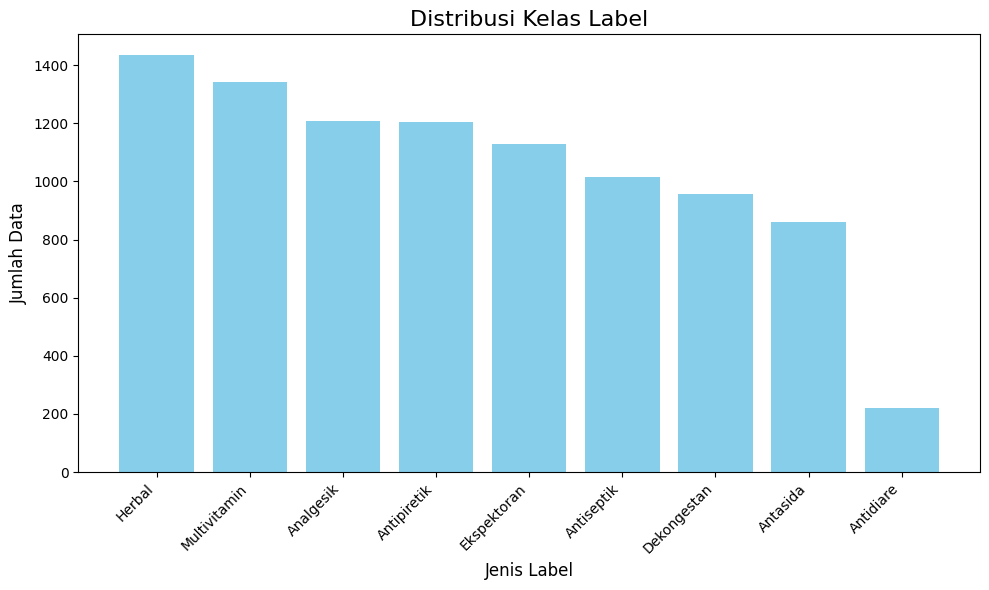

In [53]:
labels_df = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count']).sort_values(by='count', ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(labels_df.index, labels_df['count'], color='skyblue')
plt.title('Distribusi Kelas Label', fontsize=16)
plt.xlabel('Jenis Label', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('../dataset/distribusi_kelas_label_hasilprediksi.png')

In [54]:
COL_PREDIKSI = 'jenis'
COL_ACTUAL   = 'Jenis Asli'

if COL_ACTUAL not in df.columns:
    print(f"⚠️ Error: Kolom '{COL_ACTUAL}' tidak ditemukan di DataFrame.")
    print("Mohon pastikan Anda sudah memuat data test yang memiliki label asli.")
    print(f"Kolom yang tersedia: {df.columns.tolist()}")
else:
    print("✅ Melakukan perhitungan metrik evaluasi...")

    def parse_labels(x):
        if pd.isna(x) or x == '':
            return []
        if isinstance(x, list):
            return x
        return [item.strip() for item in str(x).split(',')]

    y_true_raw = df[COL_ACTUAL].apply(parse_labels)
    y_pred_raw = df[COL_PREDIKSI].apply(parse_labels)

    mlb = MultiLabelBinarizer()
    
    mlb.fit(pd.concat([y_true_raw, y_pred_raw]))
    
    y_true_bin = mlb.transform(y_true_raw)
    y_pred_bin = mlb.transform(y_pred_raw)

    f1_micro = f1_score(y_true_bin, y_pred_bin, average='micro')
    prec_micro = precision_score(y_true_bin, y_pred_bin, average='micro')
    recall_micro = recall_score(y_true_bin, y_pred_bin, average='micro')
    h_loss = hamming_loss(y_true_bin, y_pred_bin)

    print("\n" + "="*30)
    print("   HASIL EVALUASI DATA TEST   ")
    print("="*30)
    print(f"F1-Score (Micro) : {f1_micro:.4f}")
    print(f"Precision (Micro): {prec_micro:.4f}")
    print(f"Recall (Micro)   : {recall_micro:.4f}")
    print(f"Hamming Loss     : {h_loss:.4f}")
    print("="*30)

✅ Melakukan perhitungan metrik evaluasi...

   HASIL EVALUASI DATA TEST   
F1-Score (Micro) : 0.9777
Precision (Micro): 0.9869
Recall (Micro)   : 0.9688
Hamming Loss     : 0.0071


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import multilabel_confusion_matrix
import numpy as np

# 1. LOAD DATA YANG SUDAH DISIMPAN (Supaya tidak perlu predict ulang)
# Pastikan path file sesuai dengan yang di-save sebelumnya
df_saved = pd.read_csv('../dataset/hasil_prediksi_obat_label.csv', sep=';')

# 2. PREPROCESSING LABEL (Mengubah String kembali menjadi List)
# Karena saat disimpan ke CSV, list berubah menjadi text (misal: "Herbal, Antiseptik")
def parse_labels(x):
    if pd.isna(x) or str(x).strip() == '':
        return []
    # Memisahkan string berdasarkan koma
    return [item.strip() for item in str(x).split(',')]

# Terapkan ke kolom 'Jenis Asli' dan 'jenis' (prediksi)
y_true_raw = df_saved['Jenis Asli'].apply(parse_labels)
y_pred_raw = df_saved['jenis'].apply(parse_labels)

# 3. BINARISASI LABEL (Siapkan data untuk Confusion Matrix)
mlb = MultiLabelBinarizer()
# Fit pada gabungan kedua kolom agar semua label unik terdeteksi
mlb.fit(pd.concat([y_true_raw, y_pred_raw]))

y_true_bin = mlb.transform(y_true_raw)
y_pred_bin = mlb.transform(y_pred_raw)

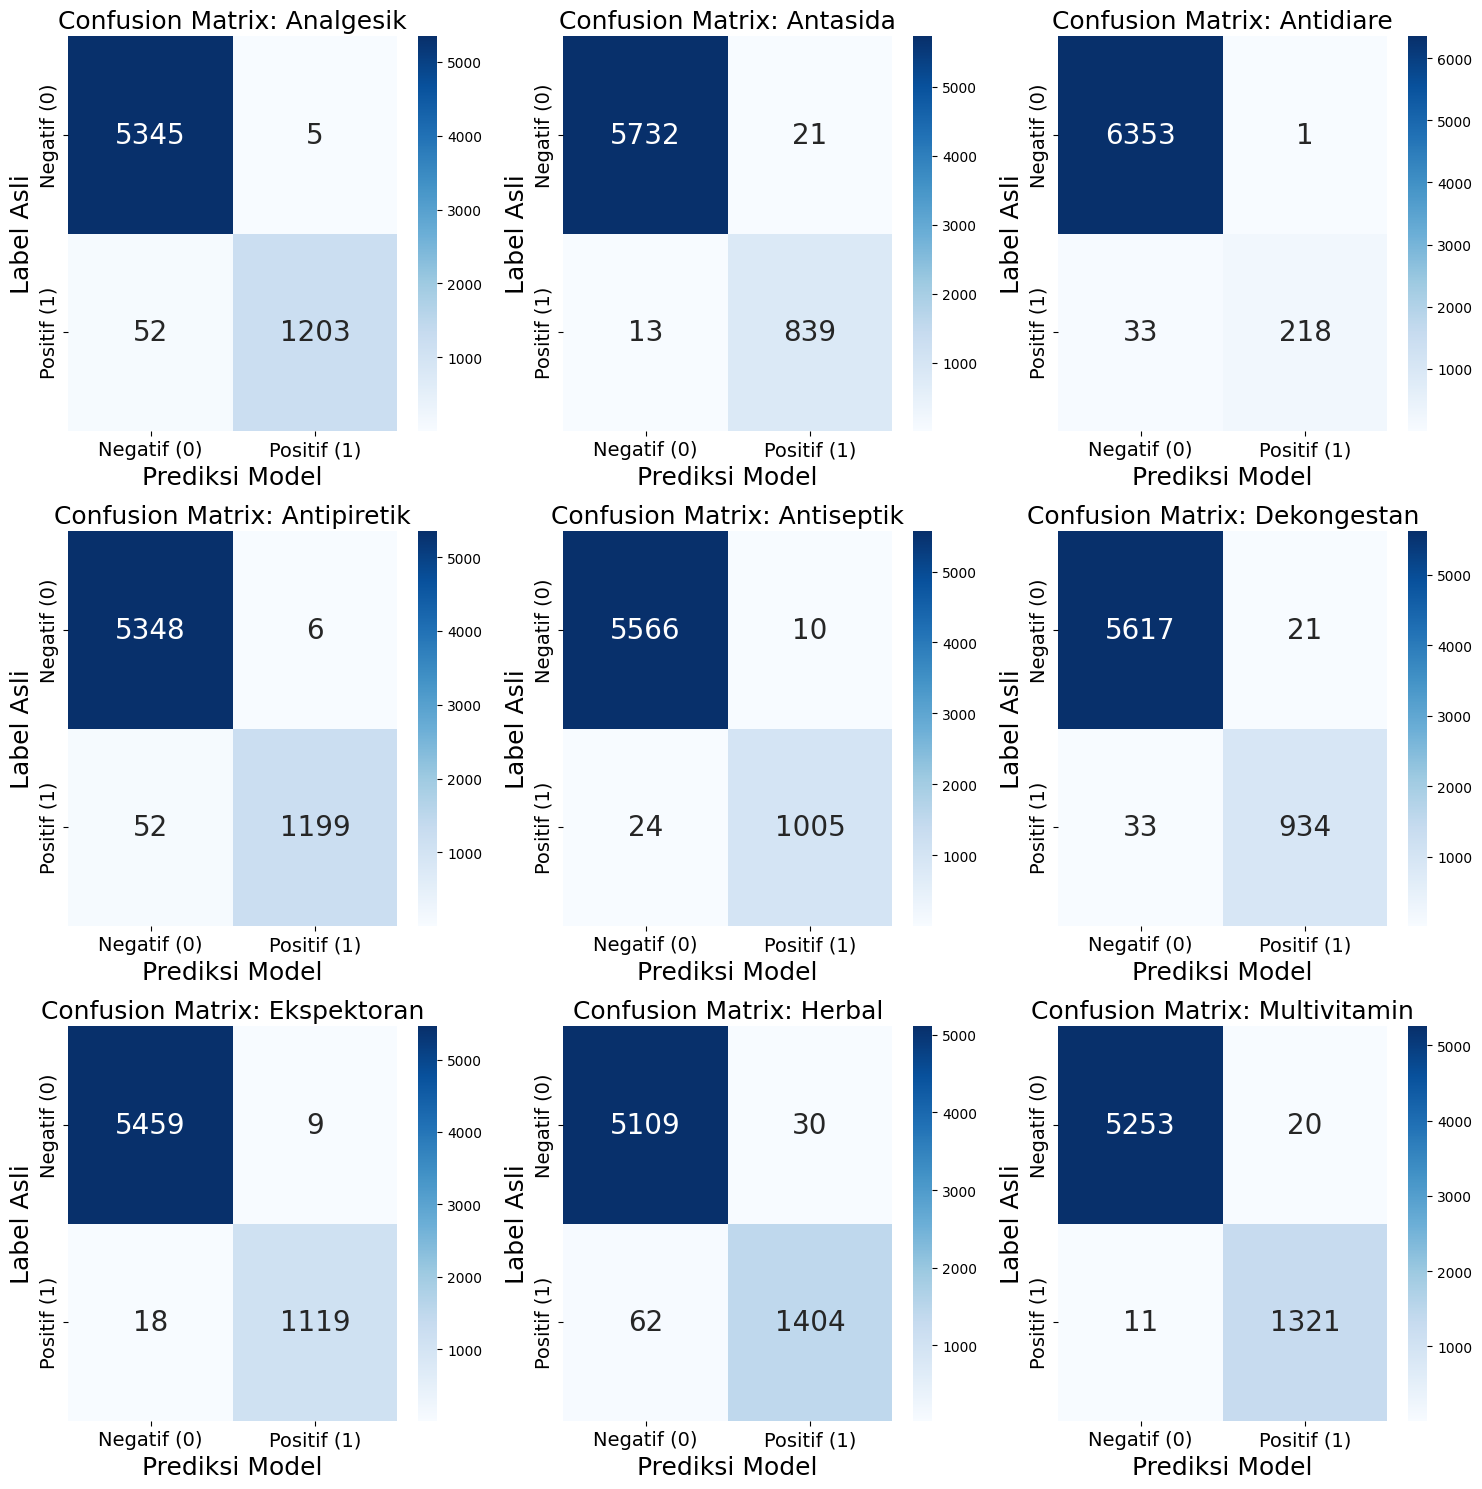

In [9]:
mcm = multilabel_confusion_matrix(y_true_bin, y_pred_bin)

labels = mlb.classes_

n_labels = len(labels)
cols = 3 
rows = (n_labels // cols) + (1 if n_labels % cols > 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, (label, matrix) in enumerate(zip(labels, mcm)):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negatif (0)', 'Positif (1)'],
                yticklabels=['Negatif (0)', 'Positif (1)'],
                annot_kws={"size": 20})
    
    axes[i].set_title(f'Confusion Matrix: {label}', fontsize=18)
    axes[i].set_xlabel('Prediksi Model', fontsize=18)
    axes[i].set_ylabel('Label Asli', fontsize=18)
    axes[i].tick_params(axis='both', which='major', labelsize=14)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
fig.savefig('../dataset/confusion_matrix_test.png', dpi=300, bbox_inches='tight')

In [56]:
df_akhir = df_clean.drop(columns=['Jenis Asli'])
# Simpan data yang bersih
df_akhir.to_csv('../dataset/data_isolation_forest_label.csv', index=False, encoding='utf-8-sig', sep=';')